# Exploratory Data Analysis
## Depression Among Type 1 Diabetes Patients — Atbra Teaching Hospital, Sudan 2025
**N = 248 | Instrument: Hamilton Depression Rating Scale (HDRS-17) | Cronbach's α = 0.913**

This notebook documents pre-analysis exploration: data quality, demographic profile, HDRS score distributions, and preliminary associations before formal SPSS analysis.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings("ignore")

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 12
sns.set_style("whitegrid")

df = pd.read_excel("../1_data/cleaned/cleaned_data.xlsx")
print(f"Dataset: {df.shape[0]} rows × {df.shape[1]} columns")
df.head(3)

Dataset: 248 rows × 59 columns


,AGE,GENDER,MARITAL,EDUCATN,EMPLOY,DIAB_DUR,TREATMNT,MED_ADHR,BS_MONIT,LAST_A1C,...,HDRS14_NUM,HDRS15_NUM,HDRS16_NUM,HDRS17_NUM,HDRS_TOTAL,DEPRESSION_STATUS,DEPRESSION_LEVEL,AGE_GROUP,DURATION_GROUP,ANY_COMPLICATION
0,20,Male,Single,Secondary School,Student,12.0,Insulin injections only,Always,Several times a week,Less than 3 months ago,...,0,0,0,0,0,0,No Depression,20-39,6-15 Years,1
1,40,Male,Married,Secondary School,Unemployed,17.0,Insulin injections only,Most of the time,Rarely,More than 6 months ago,...,0,0,2,1,18,1,Moderate,40 and Over,Over 15 Years,1
2,30,Male,Single,Secondary School,Employed,1.0,Insulin injections only,Always,Daily,Less than 3 months ago,...,0,0,0,0,0,0,No Depression,20-39,0-5 Years,0


## 1. Data Quality

In [2]:
# Missing values check
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if missing.empty:
    print("No missing values in the cleaned dataset.")
else:
    print(missing)

No missing values in the cleaned dataset.


In [3]:
# Confirm HDRS_TOTAL and depression variables
for col in ["HDRS_TOTAL", "DEPRESSION_STATUS", "DEPRESSION_LEVEL"]:
    if col in df.columns:
        print(
            f"{col}: {df[col].describe().to_dict() if col == 'HDRS_TOTAL' else df[col].value_counts().to_dict()}"
        )

HDRS_TOTAL: {'count': 248.0, 'mean': 15.149193548387096, 'std': 9.88342575275196, 'min': 0.0, '25%': 7.75, '50%': 13.5, '75%': 22.0, 'max': 43.0}
DEPRESSION_STATUS: {1: 186, 0: 62}
DEPRESSION_LEVEL: {'Mild': 91, 'No Depression': 62, 'Severe': 50, 'Moderate': 45}


## 2. Demographic Profile

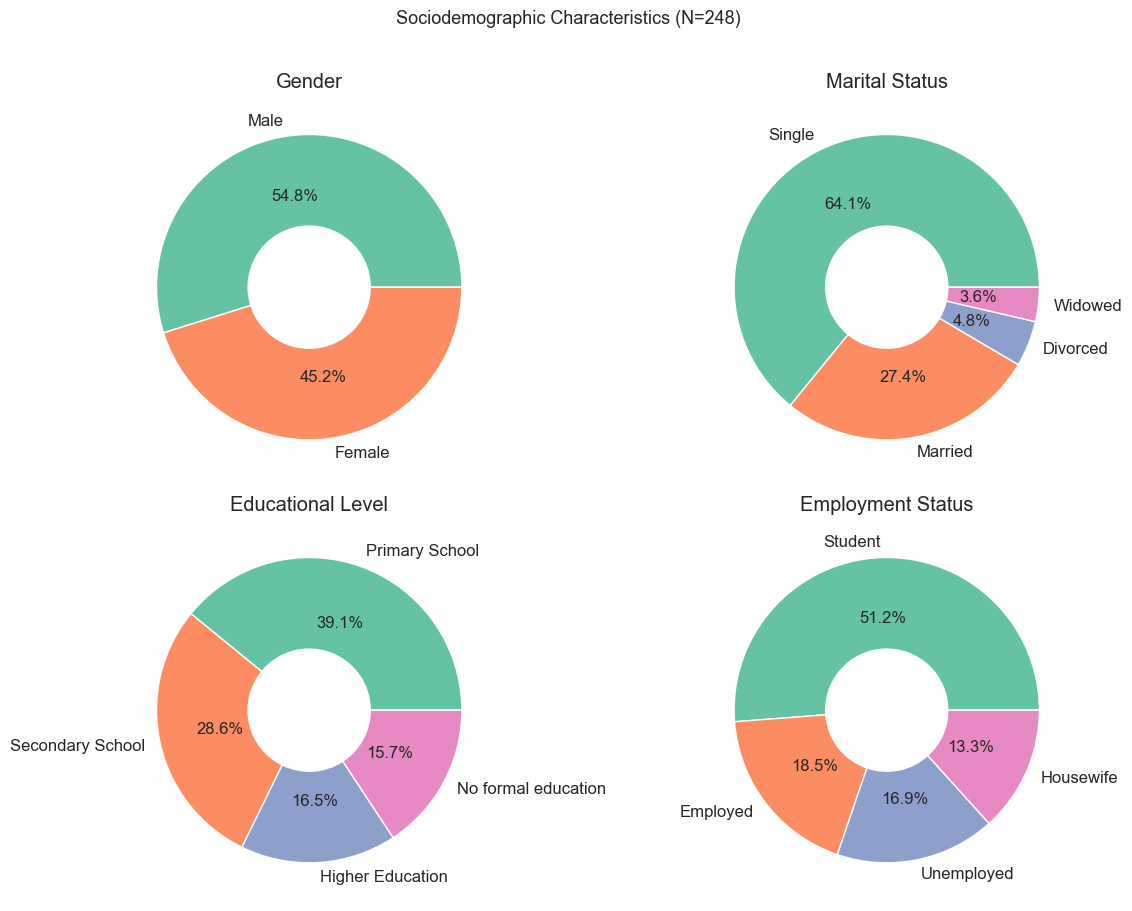

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle("Sociodemographic Characteristics (N=248)", fontsize=13, y=1.01)
palette = sns.color_palette("Set2")

for ax, (col, title) in zip(
    axes.flat,
    [
        ("GENDER", "Gender"),
        ("MARITAL", "Marital Status"),
        ("EDUCATN", "Educational Level"),
        ("EMPLOY", "Employment Status"),
    ],
):
    counts = df[col].value_counts()
    ax.pie(
        counts,
        labels=counts.index,
        autopct="%1.1f%%",
        colors=palette,
        wedgeprops={"width": 0.6, "edgecolor": "white"},
    )
    ax.set_title(title)
plt.tight_layout()
plt.show()

## 3. Clinical Characteristics

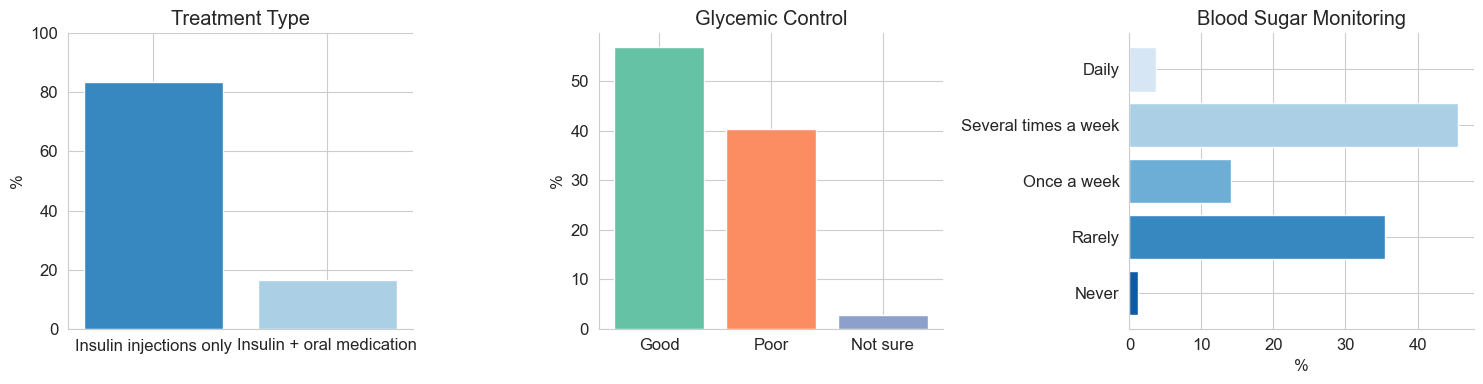

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Treatment type
counts = df["TREATMNT"].value_counts()
axes[0].bar(
    counts.index, counts.values / len(df) * 100, color=sns.color_palette("Blues_r", 2)
)
axes[0].set_title("Treatment Type")
axes[0].set_ylabel("%")
axes[0].set_ylim(0, 100)

# Glycemic control
counts = df["GLY_CTRL"].value_counts()
axes[1].bar(
    counts.index, counts.values / len(df) * 100, color=sns.color_palette("Set2")
)
axes[1].set_title("Glycemic Control")
axes[1].set_ylabel("%")

# Monitoring frequency
monit_order = ["Daily", "Several times a week", "Once a week", "Rarely", "Never"]
counts = df["BS_MONIT"].value_counts().reindex(monit_order).dropna()
axes[2].barh(
    counts.index[::-1],
    counts.values[::-1] / len(df) * 100,
    color=sns.color_palette("Blues_r", len(counts)),
)
axes[2].set_title("Blood Sugar Monitoring")
axes[2].set_xlabel("%")

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

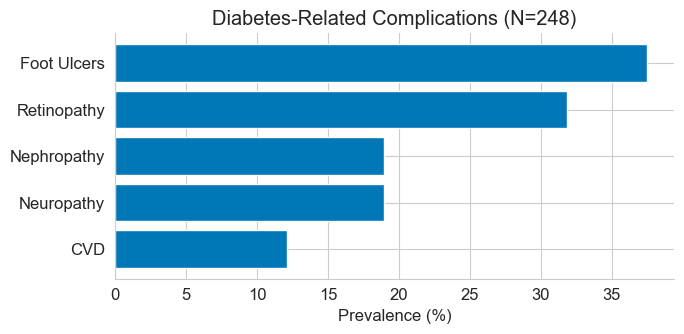

No complications reported: 85.5% of sample


In [7]:
# Complications prevalence
comp_map = {
    "COMP_FOOT": "Foot Ulcers",
    "COMP_RET": "Retinopathy",
    "COMP_NEUR": "Neuropathy",
    "COMP_NEPH": "Nephropathy",
    "COMP_CVD": "CVD",
}
comp_pcts = {label: df[col].mean() * 100 for col, label in comp_map.items()}
comp_pcts = dict(sorted(comp_pcts.items(), key=lambda x: x[1]))

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(list(comp_pcts.keys()), list(comp_pcts.values()), color="#0077B6")
ax.set_xlabel("Prevalence (%)")
ax.set_title("Diabetes-Related Complications (N=248)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

print(f"No complications reported: {df['COMP_NONE'].mean() * 100:.1f}% of sample")

## 4. HDRS Score Distribution

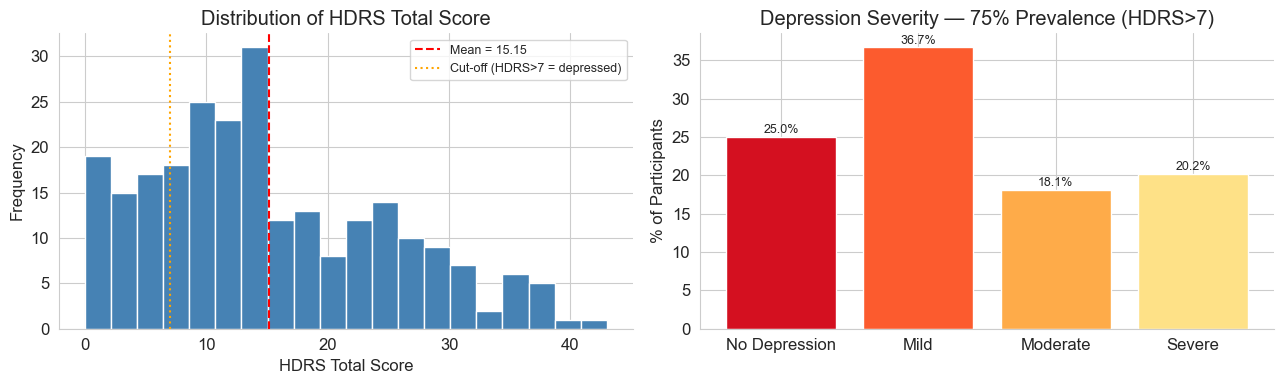

Mean HDRS: 15.15 ± 9.88
Range: 0 – 43
Depressed (HDRS>7): 75.0%


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df["HDRS_TOTAL"].dropna(), bins=20, color="steelblue", edgecolor="white")
axes[0].axvline(
    df["HDRS_TOTAL"].mean(),
    color="red",
    linestyle="--",
    label=f"Mean = {df['HDRS_TOTAL'].mean():.2f}",
)
axes[0].axvline(7, color="orange", linestyle=":", label="Cut-off (HDRS>7 = depressed)")
axes[0].set_xlabel("HDRS Total Score")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of HDRS Total Score")
axes[0].legend(fontsize=9)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

sev_order = ["No Depression", "Mild", "Moderate", "Severe"]
counts = df["DEPRESSION_LEVEL"].value_counts().reindex(sev_order).dropna()
axes[1].bar(
    counts.index, counts.values / len(df) * 100, color=sns.color_palette("YlOrRd_r", 4)
)
for i, v in enumerate(counts.values / len(df) * 100):
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=9)
axes[1].set_ylabel("% of Participants")
axes[1].set_title("Depression Severity — 75% Prevalence (HDRS>7)")
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

print(f"Mean HDRS: {df['HDRS_TOTAL'].mean():.2f} ± {df['HDRS_TOTAL'].std():.2f}")
print(f"Range: {df['HDRS_TOTAL'].min():.0f} – {df['HDRS_TOTAL'].max():.0f}")
print(f"Depressed (HDRS>7): {df['DEPRESSION_STATUS'].mean() * 100:.1f}%")

## 5. Key Associations

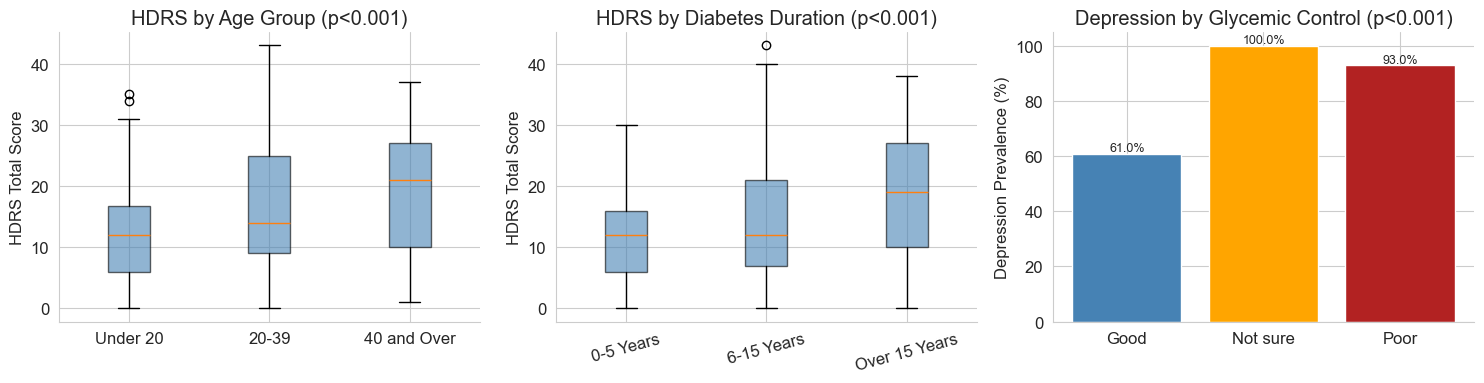

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# HDRS by age group
age_order = ["Under 20", "20-39", "40 and Over"]
groups = [df.loc[df["AGE_GROUP"] == g, "HDRS_TOTAL"].dropna() for g in age_order]
axes[0].boxplot(
    groups,
    labels=age_order,
    patch_artist=True,
    boxprops=dict(facecolor="steelblue", alpha=0.6),
)
f, p = stats.f_oneway(*[g for g in groups if len(g) > 0])
axes[0].set_title("HDRS by Age Group (p<0.001)")
axes[0].set_ylabel("HDRS Total Score")
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# HDRS by diabetes duration
dur_order = ["0-5 Years", "6-15 Years", "Over 15 Years"]
groups = [df.loc[df["DURATION_GROUP"] == g, "HDRS_TOTAL"].dropna() for g in dur_order]
axes[1].boxplot(
    groups,
    labels=dur_order,
    patch_artist=True,
    boxprops=dict(facecolor="steelblue", alpha=0.6),
)
axes[1].set_title("HDRS by Diabetes Duration (p<0.001)")
axes[1].set_ylabel("HDRS Total Score")
axes[1].tick_params(axis="x", rotation=15)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

# Depression by glycemic control
dep_ctrl = df.groupby("GLY_CTRL")["DEPRESSION_STATUS"].mean() * 100
dep_ctrl = dep_ctrl.reindex(["Good", "Not sure", "Poor"]).dropna()
axes[2].bar(dep_ctrl.index, dep_ctrl.values, color=["steelblue", "orange", "firebrick"])
for i, v in enumerate(dep_ctrl.values):
    axes[2].text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=9)
axes[2].set_ylabel("Depression Prevalence (%)")
axes[2].set_title("Depression by Glycemic Control (p<0.001)")
axes[2].spines["top"].set_visible(False)
axes[2].spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [10]:
# Pearson correlations: age, diabetes duration, HDRS total
pairs = [("AGE", "HDRS_TOTAL"), ("DIAB_DUR", "HDRS_TOTAL"), ("AGE", "DIAB_DUR")]
print("Pearson Correlations:")
for a, b in pairs:
    r, p = stats.pearsonr(df[a].dropna(), df.loc[df[a].notna() & df[b].notna(), b])
    print(f"  {a} ↔ {b}: r={r:.3f}, p={p:.4f}")

Pearson Correlations:
  AGE ↔ HDRS_TOTAL: r=0.315, p=0.0000
  DIAB_DUR ↔ HDRS_TOTAL: r=0.326, p=0.0000
  AGE ↔ DIAB_DUR: r=0.921, p=0.0000


## Summary of EDA Findings

| Finding | Value |
|---------|-------|
| Sample size | N = 248 |
| Mean age | 23.35 ± 12.84 years |
| Mean diabetes duration | 12.78 ± 9.26 years |
| Insulin only treatment | 83.5% |
| Good glycemic control | 56.9% |
| Foot ulcers | 37.5% |
| Retinopathy | 31.9% |
| Mean HDRS score | 15.15 ± 9.88 |
| Depression prevalence (HDRS > 7) | 75.0% |
| HDRS reliability (Cronbach's α) | 0.913 |
| Age ↔ HDRS correlation | r = 0.315 (p<0.001) |
| Diabetes duration ↔ HDRS | r = 0.326 (p<0.001) |
| Poor glycemic control → depression | 93.0% |
| Foot ulcers → depression | 91.4% |

Formal bivariate and multivariate analysis conducted in SPSS (see `4_analysis/full_analysis.sps`).
